* This notebook uses the Prophet model to forecast the NASDAQ (^IXIC) index.

* The method captures overall trend behavior and produces medium- and long-term projections.

In [6]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet

In [8]:
df_raw = pd.read_csv("../data/ixic.csv", parse_dates=["Date"])
df_raw = df_raw.sort_values("Date")
y = df_raw.set_index("Date")["^IXIC"]
y.name = "ixic_close"
df_prophet = y.reset_index()
df_prophet.columns = ["ds", "y"]

print("Start:", y.index.min().date())
print("End:", y.index.max().date())
print("Observations:", len(y))

Start: 2016-01-04
End: 2026-02-20
Observations: 2548


In [10]:
prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

prophet_model.fit(df_prophet)

02:38:04 - cmdstanpy - INFO - Chain [1] start processing
02:38:04 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
H = 5

future_dates = pd.bdate_range(start=y.index[-1], periods=H+1)[1:]
future = pd.DataFrame({"ds": future_dates})
forecast = prophet_model.predict(future)

fc_prophet = forecast.set_index("ds")["yhat"]
print("\nProphet 5-day forecast:")
print(fc_prophet)


Prophet 5-day forecast:
ds
2026-02-23    23315.510076
2026-02-24    23326.176691
2026-02-25    23336.843306
2026-02-26    23347.509921
2026-02-27    23358.176535
Name: yhat, dtype: float64


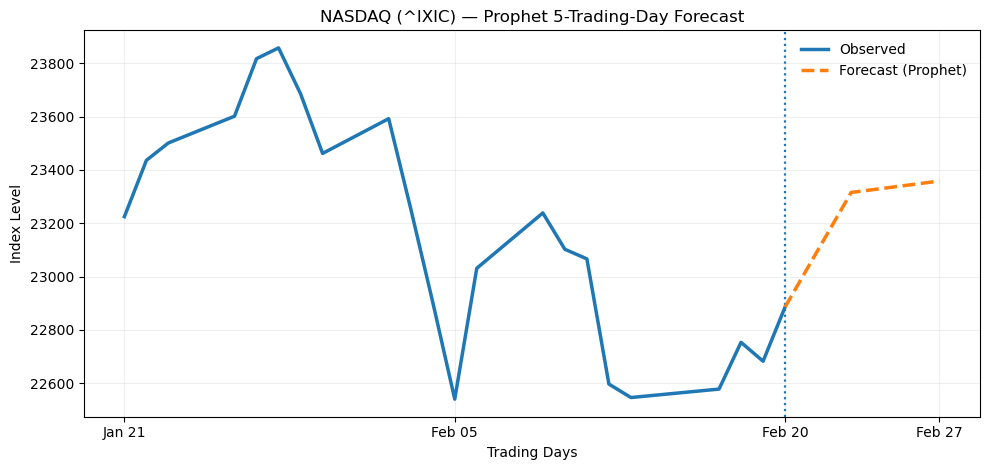

In [16]:
window = 22
hist = y.iloc[-window:]
last_date = hist.index[-1]
plt.figure(figsize=(10,4.8))

plt.plot(hist.index, hist.values, linewidth=2.5, label="Observed")

x_fc = pd.DatetimeIndex([last_date]).append(fc_prophet.index)
y_fc = np.r_[hist.iloc[-1], fc_prophet.values]

plt.axvline(last_date, linestyle=":", linewidth=1.6)
plt.plot(x_fc, y_fc, linestyle="--", linewidth=2.5, label="Forecast (Prophet)")
plt.title("NASDAQ (^IXIC) — Prophet 5-Trading-Day Forecast")
plt.xlabel("Trading Days")
plt.ylabel("Index Level")

ax = plt.gca()
tick_dates = pd.to_datetime(sorted(set([
    hist.index[0],
    hist.index[len(hist)//2],
    last_date,
    fc_prophet.index[-1]
])))
ax.set_xticks(tick_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.grid(True, alpha=0.2)
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

In [18]:
prophet_table = pd.DataFrame({
    "Forecast_Date": fc_prophet.index,
    "Prophet_Forecast": fc_prophet.values
})

prophet_table["Forecast_Date"] = prophet_table["Forecast_Date"].dt.strftime("%Y-%m-%d")
prophet_table

,Forecast_Date,Prophet_Forecast
0,2026-02-23,23315.510076
1,2026-02-24,23326.176691
2,2026-02-25,23336.843306
3,2026-02-26,23347.509921
4,2026-02-27,23358.176535


* The Prophet model captures the overall trend of the NASDAQ index rather than short-term autocorrelation.
* The estimated trend is upward, indicating long-run growth, while daily volatility is smoothed.
* The 5-trading-day forecast suggests a small gradual increase in the index level. The prediction interval widens across days, reflecting growing uncertainty further into the future.